For each product, candidate images were retrieved by text search using the product name. Candidates were ranked by string similarity to the Instacart product name, and the top-ranked image was selected when the candidate set was judged to be on-topic overall. When multiple high-scoring candidates were similar, the highest-scoring candidate was retained rather than treating the ambiguity as an automatic exclusion, since many grocery items do not map to a single uniquely branded presentation.

In [1]:
import pandas as pd
import numpy as np
import requests
import time
import re
from difflib import SequenceMatcher

# load in 

In [2]:
products = pd.read_csv("products.csv")
order_products_prior = pd.read_csv("order_products_prior.csv")

print(products.head())
print(order_products_prior.head())

   product_id                                       product_name  aisle_id  \
0           1                         Chocolate Sandwich Cookies        61   
1           2                                   All-Seasons Salt       104   
2           3               Robust Golden Unsweetened Oolong Tea        94   
3           4  Smart Ones Classic Favorites Mini Rigatoni Wit...        38   
4           5                          Green Chile Anytime Sauce         5   

   department_id  
0             19  
1             13  
2              7  
3              1  
4             13  
   order_id  product_id  add_to_cart_order  reordered
0         2       33120                  1          1
1         2       28985                  2          1
2         2        9327                  3          0
3         2       45918                  4          1
4         2       30035                  5          0


# reorder frequencies

In [3]:
# Compute average reordered per product:
# since reordered is 0/1 at the order-row level, the mean is the fraction of purchases that were reorders
product_reorder_stats = (
    order_products_prior
    .groupby("product_id")["reordered"]
    .mean()
    .reset_index()
    .rename(columns={"reordered": "average_reordered"})
)

# Merge with product names
product_df = products[["product_id", "product_name"]].merge(
    product_reorder_stats,
    on="product_id",
    how="inner"
)

print(product_df.head())
print(product_df.shape)

   product_id                                       product_name  \
0           1                         Chocolate Sandwich Cookies   
1           2                                   All-Seasons Salt   
2           3               Robust Golden Unsweetened Oolong Tea   
3           4  Smart Ones Classic Favorites Mini Rigatoni Wit...   
4           5                          Green Chile Anytime Sauce   

   average_reordered  
0           0.613391  
1           0.133333  
2           0.732852  
3           0.446809  
4           0.600000  
(49677, 3)


### they do be lovin that robust golden unsweetened oolong tea
# labelling reordered vs never-again products 

In [4]:
q25 = product_df["average_reordered"].quantile(0.25)
q75 = product_df["average_reordered"].quantile(0.75)

product_df["low_reorder"] = (product_df["average_reordered"] <= q25).astype(int)
product_df["high_reorder"] = (product_df["average_reordered"] >= q75).astype(int)

# Sanity check: middle 50% should have both flags = 0
print("q25:", q25)
print("q75:", q75)

print(product_df[["low_reorder", "high_reorder"]].value_counts())

q25: 0.2080745341614907
q75: 0.5293066476054324
low_reorder  high_reorder
0            0               24837
             1               12420
1            0               12420
Name: count, dtype: int64


# tossing large grey-area
### invoking that freak from sonic the hedgehog

In [5]:
tails_df = product_df[
    (product_df["low_reorder"] == 1) | (product_df["high_reorder"] == 1)
].copy()

print(tails_df.head())
print(tails_df.shape)

    product_id                          product_name  average_reordered  \
0            1            Chocolate Sandwich Cookies           0.613391   
1            2                      All-Seasons Salt           0.133333   
2            3  Robust Golden Unsweetened Oolong Tea           0.732852   
4            5             Green Chile Anytime Sauce           0.600000   
10          11                     Peach Mango Juice           0.567308   

    low_reorder  high_reorder  
0             0             1  
1             1             0  
2             0             1  
4             0             1  
10            0             1  
(24840, 5)


# cleaning and scoring functions

In [6]:
def clean_product_name(name):
    """
    Light normalization for search.
    Keeps the query recognizable while removing punctuation noise.
    """
    if pd.isna(name):
        return ""
    
    name = str(name).lower().strip()
    name = name.replace("&", " and ")
    name = re.sub(r"[^a-z0-9\s]+", " ", name)
    name = re.sub(r"\s+", " ", name).strip()
    return name


def similarity(a, b):
    """
    Simple string similarity score between 0 and 1.
    """
    return SequenceMatcher(None, str(a).lower(), str(b).lower()).ratio()

# search open food facts (s.o.f.f.)

In [7]:
import requests

HEADERS = {
    "User-Agent": "ChapmanInstacartImageProject/0.1 (student project; contact@example.com)"
}

def search_open_food_facts(query, page_size=5):
    """
    Search Open Food Facts using a text query.
    Uses the older v1 search style because OFF docs note that full-text search
    is supported there, while v2 search is mainly for filtered search.
    """
    url = "https://world.openfoodfacts.net/cgi/search.pl"
    params = {
        "search_terms": query,
        "search_simple": 1,
        "action": "process",
        "json": 1,
        "page_size": page_size
    }

    response = requests.get(url, params=params, headers=HEADERS, timeout=30)

    # Helpful debug print if OFF gets grumpy again
    if response.status_code != 200:
        print("STATUS:", response.status_code)
        print("URL:", response.url)
        print("TEXT PREVIEW:", response.text[:500])

    response.raise_for_status()
    data = response.json()
    return data.get("products", [])

# score interpreter 

In [8]:
def choose_best_off_candidate(instacart_name, candidates, min_score=0.45):
    """
    Choose the best Open Food Facts candidate for an Instacart product name.
    
    Heuristic:
    - score all candidates by name similarity
    - choose the top-scoring candidate
    - accept it if the top score is at least min_score
    - if many top candidates are close, that's okay; still choose top1
    - reject only if all candidates are weak
    """
    if not candidates:
        return None
    
    scored = []
    for cand in candidates:
        cand_name = cand.get("product_name", "") or ""
        score = similarity(instacart_name, cand_name)
        scored.append((score, cand))
    
    scored.sort(key=lambda x: x[0], reverse=True)
    
    top_score, top_candidate = scored[0]
    
    if top_score < min_score:
        return None
    
    return {
        "off_product_name": top_candidate.get("product_name", None),
        "image_url": (
            top_candidate.get("image_front_url")
            or top_candidate.get("image_url")
            or top_candidate.get("image_front_small_url")
        ),
        "match_score": top_score
    }

# test

In [9]:
test_candidates = search_open_food_facts("banana", page_size=3)
print(len(test_candidates))
for c in test_candidates[:3]:
    print(c.get("product_name"), c.get("image_front_url"))

3
Yogurt Bnine BANANA https://images.openfoodfacts.net/images/products/611/124/210/2941/front_en.47.400.jpg
5 Banana Lunchbox Loaves https://images.openfoodfacts.net/images/products/501/873/522/4931/front_en.24.400.jpg
Huel Ready-To-Drink - Banana https://images.openfoodfacts.net/images/products/506/049/511/6988/front_en.49.400.jpg


# scrape

In [10]:
def match_products_to_off_images(df, max_products=None, sleep_time=0.1, print_every=10):
    """
    For each product in df, search Open Food Facts and choose a best image match.

    Returns a dataframe with:
    - product_id
    - product_name
    - average_reordered
    - low_reorder
    - high_reorder
    - off_product_name
    - image_url
    - match_score
    """
    if max_products is not None:
        df = df.head(max_products).copy()

    matched_rows = []
    total = len(df)

    for i, (_, row) in enumerate(df.iterrows(), start=1):
        product_id = row["product_id"]
        product_name = row["product_name"]
        avg_reordered = row["average_reordered"]
        low_reorder = row["low_reorder"]
        high_reorder = row["high_reorder"]

        query = clean_product_name(product_name)

        try:
            candidates = search_open_food_facts(query, page_size=5)
            best = choose_best_off_candidate(product_name, candidates, min_score=0.45)

            if best is not None and best["image_url"] is not None:
                matched_rows.append({
                    "product_id": product_id,
                    "product_name": product_name,
                    "average_reordered": avg_reordered,
                    "low_reorder": low_reorder,
                    "high_reorder": high_reorder,
                    "off_product_name": best["off_product_name"],
                    "image_url": best["image_url"],
                    "match_score": best["match_score"]
                })

        except Exception as e:
            print(f"[{i}/{total}] Skipping '{product_name}' due to error: {e}")

        if i % print_every == 0 or i == total:
            print(f"[{i}/{total}] done | matches kept: {len(matched_rows)} | latest query: {product_name}")

        time.sleep(sleep_time)
    if i % 50 == 0:
        pd.DataFrame(matched_rows).to_csv("matched_partial.csv", index=False)
    return pd.DataFrame(matched_rows)

# test

In [11]:
matched_df_small = match_products_to_off_images(tails_df, max_products=500, sleep_time=0.05)

print(matched_df_small.head())
print(matched_df_small.shape)

[10/500] done | matches kept: 1 | latest query: Gluten Free Quinoa Three Cheese & Mushroom Blend
[20/500] done | matches kept: 3 | latest query: Organic Sourdough Einkorn Crackers Rosemary
[30/500] done | matches kept: 6 | latest query: Mirabelle Brut Rose
[40/500] done | matches kept: 9 | latest query: Wild Albacore Tuna No Salt Added
[50/500] done | matches kept: 11 | latest query: Peanut Butter & Strawberry Jam Sandwich
[60/500] done | matches kept: 13 | latest query: Scooby-Doo! Fruit Flavored Snacks
[70/500] done | matches kept: 18 | latest query: Brioche Bachelor Loaf
[80/500] done | matches kept: 22 | latest query: Organic Ranch Veggie Dip
[90/500] done | matches kept: 26 | latest query: Organic Mini Homestyle Waffles
[100/500] done | matches kept: 31 | latest query: Vegan Santa Fe Style Flour Tortilla Rolled Tacos
[110/500] done | matches kept: 32 | latest query: Rescue Remedy, Spray
[120/500] done | matches kept: 36 | latest query: 3 Seed Blue Corn Dipping Chips
[130/500] done

In [16]:
matched_df_small['image_url'][0]

'https://images.openfoodfacts.net/images/products/501/010/224/3736/front_en.5.400.jpg'

Text(0.5, 1.0, 'low-repeat vs high-repeat quartiles')

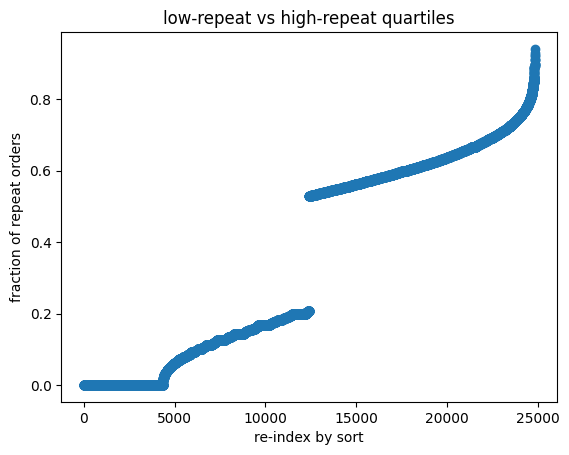

In [14]:
import matplotlib.pyplot as plt
plt.scatter(range(24840),tails_df['average_reordered'].sort_values())
plt.xlabel('re-index by sort')
plt.ylabel('fraction of repeat orders')
plt.title('low-repeat vs high-repeat quartiles')

In [15]:
matched_df_small

,product_id,product_name,average_reordered,low_reorder,high_reorder,off_product_name,image_url,match_score
0,11,Peach Mango Juice,0.567308,0,1,Peach and mango juice,https://images.openfoodfacts.net/images/produc...,0.894737
1,34,Peanut Butter Cereal,0.600979,0,1,Peanut Butter Clusters,https://images.openfoodfacts.net/images/produc...,0.809524
2,41,Organic Sourdough Einkorn Crackers Rosemary,0.653061,0,1,"Crackers, Organic Einkorn Sourdough, Rosemary",https://images.openfoodfacts.net/images/produc...,0.590909
3,43,Organic Clementines,0.153846,1,0,Brassé clémentine,https://images.openfoodfacts.net/images/produc...,0.666667
4,46,Raisin Cinnamon Bagels 5 count,0.768212,0,1,Cinnamon Raisin Bagel 6 Count,https://images.openfoodfacts.net/images/produc...,0.711864
...,...,...,...,...,...,...,...,...
130,958,Almond Extract,0.044118,1,0,Almond Extract,https://images.openfoodfacts.net/images/produc...,1.000000
131,964,Toothpicks,0.000000,1,0,Toothpicks,https://images.openfoodfacts.net/images/produc...,1.000000
132,973,8 X 6 Cutting Board,0.000000,1,0,Cutting board oil,https://images.openfoodfacts.net/images/produc...,0.722222
133,983,Strawberry Pomegranate,0.142857,1,0,Corner plant-based strawberry & pomegranate,https://images.openfoodfacts.net/images/produc...,0.676923


In [20]:
matched_df_small.to_csv('matched_SMALL.csv',index=False)